In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Spatial and k-Space Normalization

We define the field of view (FOV) to be identical for both Cartesian (uniform phase encoding)
and concentric ring trajectory (CRT) sampling and normalize it to

$$
\mathrm{FOV} = 1 .
$$

The reconstructed image is interpreted as one spatial period of a periodic object.
With \(N\) pixels per spatial dimension, the spatial sampling interval is

$$
\Delta x = \frac{\mathrm{FOV}}{N} = \frac{1}{N},
$$

resulting in an \(N \times N\) discrete image grid.

The spatial sample locations are given by

$$
\mathbf{x}_n = \frac{1}{N}(n_x,n_y),
\qquad
n_x,n_y \in \left\{-\tfrac{N}{2},\dots,\tfrac{N}{2}-1\right\},
$$

which correspond to spatial coordinates

$$
\mathbf{x}_n \in (-0.5,\,0.5)\times(-0.5,\,0.5).
$$

---

## k-Space Support and Nyquist Conditions

Sampling the image on a discrete spatial grid with spacing \(\Delta x\) imposes a
Nyquist-limited maximum spatial frequency

$$
k_{\max} = \frac{1}{2\,\Delta x} = \frac{N}{2},
$$

which determines the achievable spatial resolution and is identical for Cartesian and CRT
sampling.

Conversely, discretizing k-space introduces a second, dual Nyquist condition. If k-space
samples are spaced by \(\Delta k\), the reconstructed image becomes periodic with period

$$
\mathrm{FOV} = \frac{1}{\Delta k}.
$$

To avoid spatial aliasing (wrap-around of the object within the FOV), the k-space sampling
interval must therefore satisfy

$$
\boxed{
\Delta k \le \frac{1}{\mathrm{FOV}}
}
$$

which, for the chosen normalization \(\mathrm{FOV} = 1\), reduces to

$$
\Delta k \le 1.
$$

In the Cartesian case, k-space samples are located at integer-valued Fourier modes

$$
\mathbf{k} = (k_x,k_y),
\qquad
k_x,k_y \in \left\{-\tfrac{N}{2},\dots,\tfrac{N}{2}-1\right\},
$$

corresponding to a k-space sampling interval \(\Delta k = 1\), which exactly satisfies the
Nyquist condition.

For CRT sampling, k-space is sampled along concentric rings with finite radial and angular
spacing. The local k-space sampling density must therefore be chosen such that the effective
radial and azimuthal sample spacings satisfy the same Nyquist condition in order to avoid
spatial aliasing.

The Fourier reconstruction kernel is evaluated as

$$
e^{i 2\pi \mathbf{k}\cdot \mathbf{x}} .
$$



# Compute Cartesian backward operator

# Compute CRT backward operator

In [3]:
import numpy as np

def image_grid_fov1(N):
    # x in (-0.5, 0.5) with spacing 1/N
    x = (np.arange(N) - N/2) / N
    X, Y = np.meshgrid(x, x, indexing="xy")
    return np.stack([X.ravel(), Y.ravel()], axis=1)  # (N^2,2)

def backward_operator_from_k(N, kx, ky, w=None, alpha="trace"):
    """
    General 2D backward operator on the fixed Cartesian image grid (FOV=1):

        x = B y
        B[n,m] = alpha * w[m] * exp(i 2π k_m · x_n)

    kx,ky: (M,) in cycles per FOV (here FOV=1) -> numerically same as cycles per unit length
    w:     quadrature / density-comp weights (M,)
    alpha: "trace" => scale so trace(BB^H) = N^2 (comparable average noise power)
    """
    r = image_grid_fov1(N)                        # (N^2,2)
    k = np.stack([kx, ky], axis=1)                # (M,2)

    phase = np.exp(2j*np.pi * (k @ r.T)).T        # (N^2, M)

    if w is None:
        w = np.ones_like(kx, dtype=float)

    B = phase * w[None, :]

    if alpha == "trace":
        diag = np.sum(np.abs(B)**2, axis=1)
        alpha_val = np.sqrt((N**2) / np.sum(diag))
        B = alpha_val * B

    return B

def cartesian_k_grid_fov1(N):
    # k in cycles per FOV=1 on the DFT grid: k = m, with x = n/N
    m = np.arange(N) - N//2
    KX, KY = np.meshgrid(m, m, indexing="xy")
    return KX.ravel(), KY.ravel()

import numpy as np

import numpy as np

def crt_2d_rings_const_theta(
    N: int,
    oversamp_factor: float = 1.0,
    N_rings: int | None = None,
    include_dc: bool = False,
    dk_target: float = 1.0,
    kmax: float | None = None,
    verbose: bool = True,
):
    """
    CRT rings with CONSTANT angular spacing for all rings.

    Nyquist condition (checked at outer ring):
        r_max * Δθ <= dk_target
    """

    if N_rings is None:
        N_rings = N

    if kmax is None:
        kmax = N / 2.0   # physical k-units for FOV=1

    dr = kmax / N_rings
    r_max = (N_rings - 0.5) * dr

    # worst-case (outer ring) Nyquist condition
    N_theta_min = int(np.ceil((2.0 * np.pi * r_max) / dk_target))
    N_theta = int(np.ceil(oversamp_factor * N_theta_min))
    N_theta = max(N_theta, 1)

    dtheta = 2.0 * np.pi / N_theta
    thetas = np.arange(N_theta) * dtheta

    if verbose:
        print("CRT configuration:")
        print(f"  N_rings           = {N_rings}")
        print(f"  N_theta (per ring)= {N_theta}")
        print(f"  kmax              = {kmax:.3f}")
        print(f"  dr                = {dr:.3f}")
        print(f"  r_max             = {r_max:.3f}")
        print(f"  Δθ                = {dtheta:.4f} rad")
        print(f"  r_max * Δθ        = {r_max * dtheta:.3f}  (<= dk_target={dk_target})")
        print(f"  Nyquist OK        = {r_max * dtheta <= dk_target}")

    kxs, kys, wts = [], [], []

    if include_dc:
        kxs.append(np.array([0.0]))
        kys.append(np.array([0.0]))
        wts.append(np.array([np.pi * (dr/2.0)**2], dtype=float))

    for j in range(N_rings):
        r = (j + 0.5) * dr
        kx = r * np.cos(thetas)
        ky = r * np.sin(thetas)
        w  = r * dr * dtheta

        kxs.append(kx)
        kys.append(ky)
        wts.append(np.full_like(kx, w, dtype=float))

    kx = np.concatenate(kxs)
    ky = np.concatenate(kys)
    w  = np.concatenate(wts)

    if verbose:
        print(f"  Total k-space points = {kx.size}")

    return kx, ky, w




In [4]:
N = 22

# --------------------
# Cartesian reference
# --------------------
kx_c, ky_c = cartesian_k_grid_fov1(N)
B_cart = backward_operator_from_k(N, kx_c, ky_c, w=None, alpha="trace")
C_cart = B_cart @ B_cart.conj().T


# --------------------
# CRT WITHOUT DC
# --------------------
kx, ky, w = crt_2d_rings_const_theta(
    N,
    oversamp_factor=1.0,
    kmax=N/2,
    dk_target=1.0,
    include_dc=False,
    verbose=True
)

B_crt = backward_operator_from_k(N, kx, ky, w=w, alpha="trace")
C_crt = B_crt @ B_crt.conj().T

CRT configuration:
  N_rings           = 22
  N_theta (per ring)= 68
  kmax              = 11.000
  dr                = 0.500
  r_max             = 10.750
  Δθ                = 0.0924 rad
  r_max * Δθ        = 0.993  (<= dk_target=1.0)
  Nyquist OK        = True
  Total k-space points = 1496


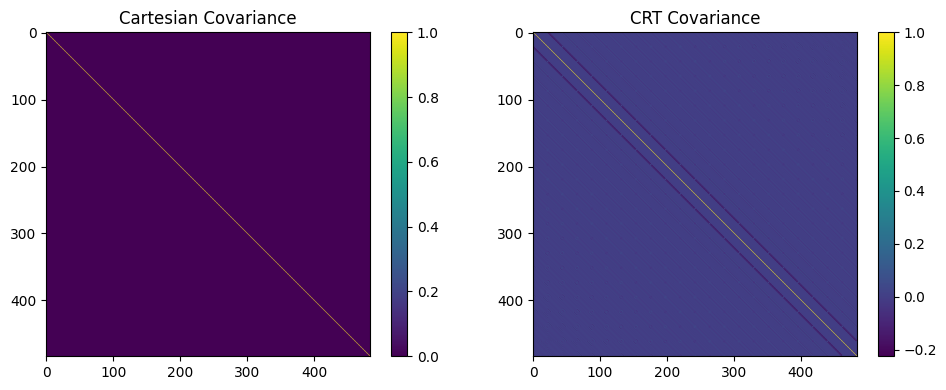

In [5]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

im0 = axs[0].imshow(np.real(C_cart), cmap="viridis")
axs[0].set_title("Cartesian Covariance")
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(np.real(C_crt), cmap="viridis")
axs[1].set_title("CRT Covariance")
plt.colorbar(im1, ax=axs[1], fraction=0.046)

plt.tight_layout()
plt.show()


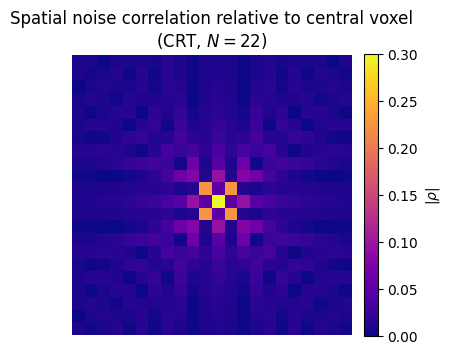

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def cov_to_corr(C):
    d = np.sqrt(np.real(np.diag(C)))
    return C / (d[:, None] * d[None, :])

def plot_corr_to_center(C, N, title="", vmax=None):
    center_idx = (N // 2) * N + (N // 2)  # row-major, center voxel
    corr = np.abs(C[center_idx, :]).reshape(N, N)

    if vmax is None:
        vmax = np.max(corr)

    im = plt.imshow(corr, cmap="plasma", vmin=0, vmax=vmax)
    plt.colorbar(im, fraction=0.046, pad=0.04, label=r"$|\rho|$")
    plt.title(title)
    plt.axis("off")

# correlation matrix
R_crt = cov_to_corr(C_crt)

plt.figure(figsize=(4,4))
plot_corr_to_center(
    R_crt,
    N,
    title="Spatial noise correlation relative to central voxel\n(CRT, $N=22$)",
    vmax=0.3   # see discussion below
)

plt.tight_layout()
plt.savefig("Fig_S1_noise_correlation.pdf", bbox_inches="tight")
plt.show()

